# Chuẩn bị dữ liệu và Entity Embeddings cho Rossmann

Qua các phần trước, chúng mình đã có một cái nhìn khá sâu về bộ dữ liệu Rossmann:  
các pattern theo thời gian, tác động của ngày lễ, khuyến mãi, cạnh tranh, v.v.

Với một chuỗi bán lẻ, đây không chỉ là “dữ liệu quá khứ”, mà thực sự là **kho tri thức** để giải bài toán rất kinh điển:

> Dự báo doanh thu theo thời gian – hay nói cách khác là dự báo lượng cầu của khách hàng.

Nếu làm tốt bài toán này, ban lãnh đạo có thể:
- Chủ động hơn trong việc chuẩn bị hàng tồn kho,
- Sắp xếp nhân sự hợp lý theo mùa vụ,
- Và vận hành chuỗi cung ứng hiệu quả hơn.

Trong notebook này, chúng mình không cố gắng tìm mô hình “xịn” nhất,  
mà tập trung vào câu hỏi:

> Với **cùng một bộ dữ liệu**, cách chuẩn bị & biểu diễn dữ liệu khác nhau  
> có thể tạo ra sự khác biệt như thế nào trong chất lượng dự báo?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.decomposition import PCA

import sys, os
sys.path.append(os.path.abspath(".."))

from data_preparation.processors import (
    RawFeatureGenerator,
    OptimizedFeatureGenerator,
    EntityEmbeddingFeatureGenerator,
)
from data_preparation.evaluator import RossmannComparer

plt.style.use("ggplot")


## 1.1 Khung phân tích: Cố định mô hình, chỉ thay đổi dữ liệu

Để phân tích cho rõ, trong Chương 2 chúng mình cố định:

- **Mô hình**: XGBoost – rất mạnh cho dữ liệu dạng bảng.
- **Metric**: RMSPE – đo xem mô hình dự đoán sai **trung bình bao nhiêu phần trăm** so với doanh thu thực tế.
- **Đầu ra**: doanh thu theo ngày của từng cửa hàng.
- **Đầu vào**: các biến về thời gian và đặc điểm cửa hàng.

Một vài quyết định tiền xử lý quan trọng:

- Loại bỏ biến **`Customers`**,
- Bỏ những ngày cửa hàng **đóng cửa** (`Open = 0`),
- Vì mục tiêu là: **trước một ngày mở cửa**, dựa trên thông tin mình biết trước, mô hình dự đoán giúp:
  > “Ngày mai cửa hàng này mở cửa thì doanh thu khoảng bao nhiêu?”

Ở các phần tiếp theo, chúng mình sẽ:
1. Xây **baseline RAW** – xử lý cực kỳ tối thiểu.
2. Xây pipeline **Business Logic Features (CLEAN)** – đối xử tử tế hơn với dữ liệu.
3. Thử một ý tưởng **Entity Embeddings** – để xem mô hình hiểu “bản sắc” của từng cửa hàng tốt đến đâu,  
   và kiểm chứng điều đó qua các biểu đồ.


In [2]:
train_df = pd.read_csv("../data/train.csv", parse_dates=["Date"], low_memory=False)
store_df = pd.read_csv("../data/store.csv")

train_df = train_df[(train_df["Sales"] > 0) & (train_df["Open"] == 1)].copy()
train_df = train_df.drop(columns="Customers")


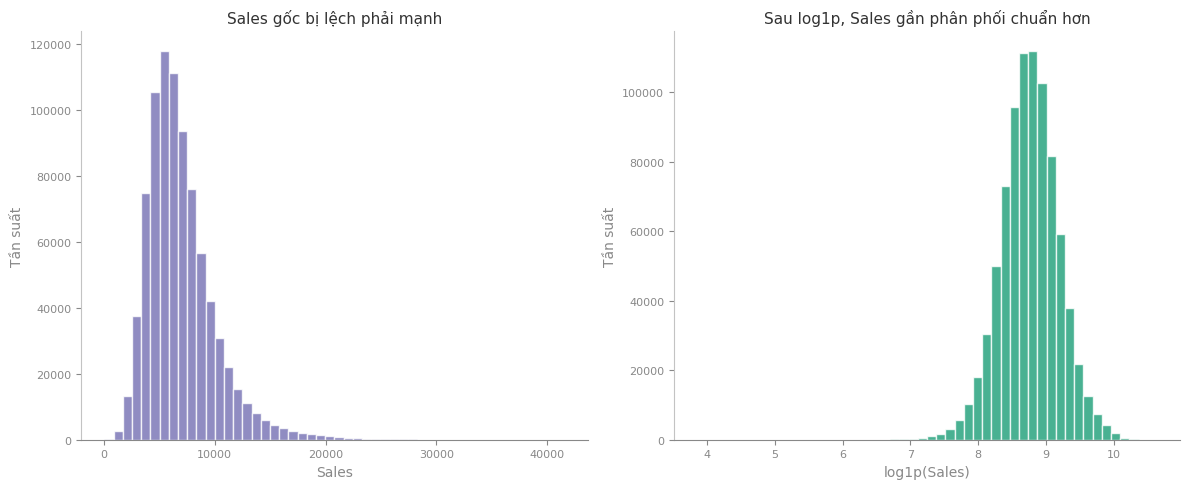

In [22]:
TEAL_BASE        = "#1B9E77"  
ORANGE_HIGHLIGHT = "#D95F02"
PURPLE_SUPPORT   = "#7570B3" 
PINK_SPECIAL     = "#E7298A"

GRAY_NEUTRAL = "#888888"
GRAY_LIGHT   = "#C3C3C3"

train_df_log_viz = train_df.copy()
train_df_log_viz["Sales_log"] = np.log1p(train_df_log_viz["Sales"])

plt.style.use("default")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY_LIGHT)
    ax.spines["bottom"].set_color(GRAY_NEUTRAL)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=8, colors=GRAY_NEUTRAL)

axes[0].hist(
    train_df_log_viz["Sales"],
    bins=50,
    color=PURPLE_SUPPORT,
    alpha=0.8,
    edgecolor="white"
)
axes[0].set_title("Sales gốc bị lệch phải mạnh", fontsize=11, color="#333333")
axes[0].set_xlabel("Sales", fontsize=10, color=GRAY_NEUTRAL)
axes[0].set_ylabel("Tần suất", fontsize=10, color=GRAY_NEUTRAL)

axes[1].hist(
    train_df_log_viz["Sales_log"],
    bins=50,
    color=TEAL_BASE,
    alpha=0.8,
    edgecolor="white"
)
axes[1].set_title("Sau log1p, Sales gần phân phối chuẩn hơn", fontsize=11, color="#333333")
axes[1].set_xlabel("log1p(Sales)", fontsize=10, color=GRAY_NEUTRAL)
axes[1].set_ylabel("Tần suất", fontsize=10, color=GRAY_NEUTRAL)

plt.tight_layout()
plt.show()


## 1.2 Phân phối doanh thu và lý do dùng log(Sales)

Trước khi cho mô hình học, chúng mình nhìn lại phân phối biến mục tiêu `Sales`.

- Ở biểu đồ bên trái, phân phối `Sales` bị **lệch phải rất mạnh**, có nhiều ngày doanh thu “khủng”.
- Điều này khiến mô hình khó học, dễ bị kéo bởi một vài điểm cực trị.

Vì vậy, chúng mình cho mô hình dự đoán trên thang **log1p(Sales)**:

- Ở biểu đồ bên phải, phân phối `log1p(Sales)` cân bằng hơn,
- Mô hình (và mạng embedding phía dưới) học **ổn định hơn**.

Sau khi dự đoán xong, chúng mình dùng `expm1` để chuyển ngược về doanh thu thực tế.


In [4]:
FIXED_PARAMS = {
    'objective': 'reg:squarederror',
    'n_estimators': 300,
    'max_depth': 10,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'n_jobs': -1,
    'random_state': 42
}

comparer = RossmannComparer(FIXED_PARAMS, train_df, store_df)

raw_proc = RawFeatureGenerator()
opt_proc  = OptimizedFeatureGenerator()
emb_proc  = EntityEmbeddingFeatureGenerator(
    model_save_path="checkpoints/emb_model_compare.pth",
    epochs=20,
    batch_size=256,
)

raw_proc, opt_proc, emb_proc


(RawFeatureGenerator(),
 OptimizedFeatureGenerator(),
 EntityEmbeddingFeatureGenerator(batch_size=256, epochs=20,
                                 model_save_path=WindowsPath('D:/dataviz_proj/data_preparation/checkpoints/emb_model_compare.pth')))

## 1.3 Baseline: Pipeline RAW – “mốc 0” tối thiểu

Bước đầu tiên, chúng mình xây một mô hình **baseline RAW**.  
Baseline giống như **mốc 0**: không kỳ vọng nó tốt, mà để biết:

> Nếu xử lý dữ liệu rất tối thiểu, mô hình sẽ cho kết quả như thế nào?

Ở pipeline RAW, chúng mình cố tình làm cực kỳ đơn giản:

- **Giá trị thiếu**: fill hết bằng `0`, chưa áp dụng logic business.
- **Thời gian**: từ `Date` chỉ tách `Year`, `Month`, `Day` – mức tối thiểu để mô hình “biết” có yếu tố thời gian.
- **Biến phân loại** (`StateHoliday`, `StoreType`, `Assortment`, `PromoInterval`, …):
  - Dùng **Label Encoding**,
  - Không dùng One-Hot để tránh nổ số chiều (hơn 1.000 cửa hàng + nhiều category).
- **Các cột không cần thiết** (như `Date` sau khi tách) được bỏ bớt.

Pipeline RAW đóng vai trò “điểm xuất phát” để so sánh với các cách chuẩn bị dữ liệu tốt hơn.


## 1.4 Pipeline Business Logic Features (CLEAN)

Từ baseline RAW, câu hỏi tự nhiên là:

> Nếu chúng ta **đối xử tử tế hơn** với dữ liệu theo đúng hiểu biết business,  
> mô hình có cải thiện rõ rệt không?

Dựa trên phân tích ở Chương 1, chúng mình thiết kế lại các đặc trưng để tạo thành pipeline  
**Business Logic Features (CLEAN)**:

- **Nhóm thời gian**: thêm `DayOfWeek`, `WeekOfYear`, `WeekOfMonth`, `IsWeekend`  
  → mô hình nhìn rõ pattern theo tuần, mùa vụ, hành vi cuối tuần.
- **Ngày lễ**: chuẩn hóa `StateHoliday` thành một cờ đơn giản `IsStateHoliday`  
  → mô hình chỉ cần biết hôm đó là ngày thường hay ngày đặc biệt.
- **Cạnh tranh**:
  - Từ `CompetitionOpenSinceYear` & `CompetitionOpenSinceMonth`  
    → gộp thành `CompetitionMonthsOpen` = số tháng đối thủ đã hiện diện.
- **Promo2**:
  - Từ các trường rời rạc (`Promo2SinceYear`, `Promo2SinceWeek`, `PromoInterval`)  
    → gộp thành `Promo2Weeks` (số tuần đã tham gia) & `IsPromo2Month` (tháng hiện tại có nằm trong promo không).

Về missing values:

- Thay vì quét hết về `0`, chúng mình dùng **median** cho các biến như `CompetitionDistance`,  
  các mốc bắt đầu cạnh tranh,… để tránh tạo ra những giá trị “0 vô nghĩa”.

Xuyên suốt CLEAN, chúng mình **vẫn dùng Label Encoding** cho toàn bộ biến phân loại:

- Giữ pipeline gọn, nhất quán với RAW,
- Phù hợp với XGBoost,
- Và đảm bảo so sánh RAW vs CLEAN là **công bằng** – khác chủ yếu ở **mức độ chuẩn hoá dữ liệu**.


## 1.5 Động lực cho Entity Embeddings

Ngay cả sau khi đã tối ưu theo logic business, vẫn còn một “nút thắt” lớn:

> Hầu hết các input quan trọng vẫn là **biến phân loại**  
> (mã cửa hàng, loại cửa hàng, ngày trong tuần, kỳ promo…).

Xử lý kiểu truyền thống:

- **One-hot encoding**:
  - Nổ số chiều, tạo ra hàng trăm/hàng nghìn cột,
  - Mô hình nặng, khó train, khó trực quan.
- **Label/Ordinal encoding**:
  - Gọn hơn, nhưng bản chất chỉ là **gán mã ID**,
  - Mô hình thấy “Store 1, Store 2, Store 3”…  
    chứ không hiểu cửa hàng nào **giống nhau** về hành vi doanh thu.

Để giải bài toán này, chúng mình thử một ý tưởng mới: **Entity Embeddings**.

### 1.6 Entity Embeddings trong pipeline của chúng mình

Trực giác:

> Thay vì coi “Store 1/2/3” hay “Mon/Tue/…” là mã rời rạc,  
> ta để mô hình **học ra một “tọa độ” (vector)** cho mỗi thực thể trong không gian nhiều chiều.

- Cửa hàng có hành vi doanh thu giống nhau → nằm **gần nhau** trong không gian embedding.
- Cửa hàng rất khác nhau → nằm **xa nhau**.

Về mặt kỹ thuật:

- Chúng mình **giữ nguyên** toàn bộ feature đã xây trong CLEAN (thời gian, cạnh tranh, promo, …),
- Các biến phân loại được đưa qua **lớp embedding** để biến từ “ID rời rạc” thành **vector số thực giàu thông tin**,
- Các vector này được dùng làm input cho mô hình dự báo, như một dạng:
  > “Chân dung hành vi” của từng cửa hàng, từng loại ngày, từng loại promo,…

Bảng dưới đây tóm tắt các biến được embedding, số lượng giá trị khác nhau và kích thước embedding tương ứng:

| Feature              | Unique | Emb Dim | Notes                      |
|----------------------|--------|---------|----------------------------|
| Store                | 1115   | 50      | ID từng cửa hàng           |
| DayOfWeek            | 7      | 4       | 0–6                        |
| Year                 | 3      | 2       | 2013–2015                  |
| Month                | 12     | 6       | 1–12                       |
| Day                  | 31     | 16      | 1–31                       |
| StateHoliday         | 4      | 2       | `0`, `a`, `b`, `c`         |
| StoreType            | 4      | 2       | a–d                        |
| Assortment           | 3      | 2       | a–c                        |
| PromoInterval        | 6      | 3       | Jan/Feb/…                  |
| WeekOfMonth          | 5      | 3       | 1–5                        |
| **Total Embedding Dim** | —  | **90**  | Tổng số chiều embedding    |

Ở phần tiếp theo, chúng mình sẽ:
- So sánh RMSPE giữa **RAW – CLEAN – Entity Embeddings**,
- Sau đó “soi” trực tiếp không gian embedding để xem nó thực sự học được gì.



In [5]:
rmspe_raw = comparer.evaluate("RAW_LabelEncode", raw_proc, use_log_target=False)
rmspe_opt = comparer.evaluate("Optimized_FE",   opt_proc, use_log_target=True)
rmspe_emb = comparer.evaluate("EntityEmbedding", emb_proc, use_log_target=True)

summary = comparer.get_summary()
summary



--- Evaluating: RAW_LabelEncode ---
Train range: 2013-01-01 -> 2015-06-18 (802,942 rows)
Test  range: 2015-06-19 -> 2015-07-31 (41,396 rows)
Preprocessing...
Training XGBoost (log target = False)...
Done. RMSPE: 0.16692

--- Evaluating: Optimized_FE ---
Train range: 2013-01-01 -> 2015-06-18 (802,942 rows)
Test  range: 2015-06-19 -> 2015-07-31 (41,396 rows)
Preprocessing...
Training XGBoost (log target = True)...
Optimizing correction factor (on TRAIN, not TEST)...
Best factor (from TRAIN): 0.9800
Done. RMSPE: 0.14387

--- Evaluating: EntityEmbedding ---
Train range: 2013-01-01 -> 2015-06-18 (802,942 rows)
Test  range: 2015-06-19 -> 2015-07-31 (41,396 rows)
Preprocessing...


d:\dataviz_proj\data_preparation\processors.py:544: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(str(self.model_save_path), map_location=self.device

Training XGBoost (log target = True)...
Optimizing correction factor (on TRAIN, not TEST)...
Best factor (from TRAIN): 0.9880
Done. RMSPE: 0.11685


,RMSPE,Features,Log Target
EntityEmbedding,0.116852,96,True
Optimized_FE,0.143872,20,True
RAW_LabelEncode,0.166923,17,False


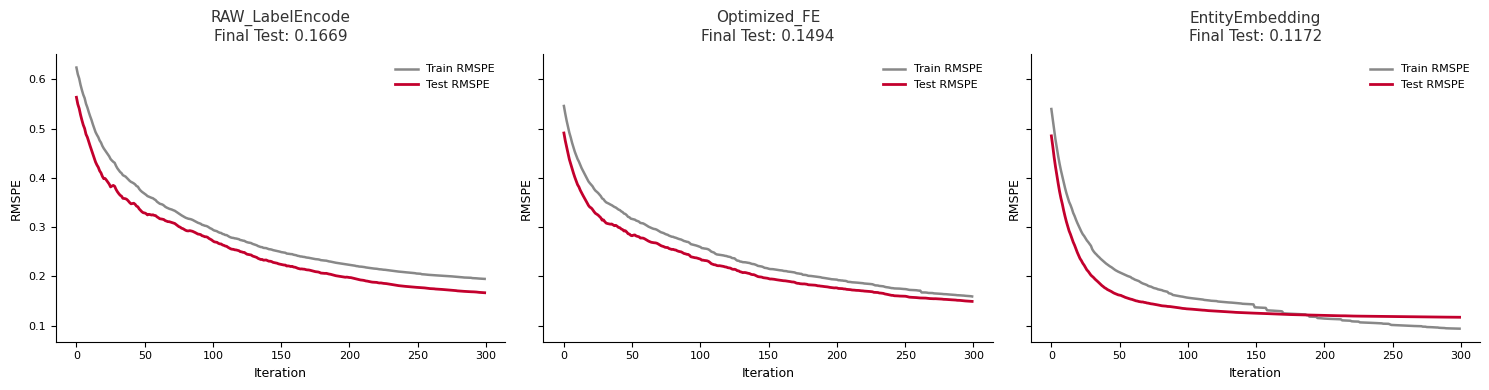

In [6]:
comparer.plot_learning_curves()


## 1.7 So sánh RMSPE: RAW vs CLEAN vs Entity Embeddings

Sau khi train cùng một mô hình XGBoost trên ba pipeline:

1. **Raw Data (Naive)** – xử lý tối thiểu,
2. **Business Logic Features (CLEAN)** – chuẩn hoá theo logic business,
3. **Entity Embeddings** – thêm lớp embedding cho các biến phân loại,

chúng mình tổng hợp RMSPE trên tập test và vẽ thành biểu đồ cột.

Trong biểu đồ:

- Mỗi cột là **RMSPE** của một pipeline (thấp hơn là tốt hơn),
- Cột **Entity Embeddings** được highlight, vì đây là pipeline tốt nhất.

Điều quan trọng là:

> Mô hình, metric, target **giữ nguyên**.  
> Sự khác biệt về chất lượng dự báo đến từ **cách chuẩn bị và biểu diễn dữ liệu**,  
> đặc biệt là cách mô hình hoá các **biến phân loại** bằng Entity Embeddings.


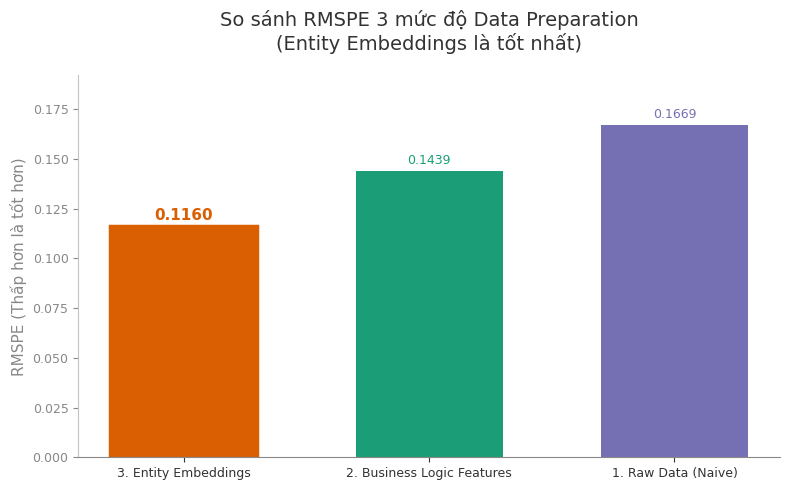

In [ ]:
labels = [
    "3. Entity Embeddings",
    "2. Business Logic Features",
    "1. Raw Data (Naive)"
]
rmspe_vals = np.array([0.1168, 0.1439, 0.1669])

# Map label -> màu trong palette mới
color_map = {
    "3. Entity Embeddings": ORANGE_HIGHLIGHT,  # tốt nhất, cần nổi
    "2. Business Logic Features": TEAL_BASE,
    "1. Raw Data (Naive)": PURPLE_SUPPORT,
}

bar_colors = [color_map[lbl] for lbl in labels]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.bar(labels, rmspe_vals, color=bar_colors, width=0.6)

ax.set_title(
    "So sánh RMSPE 3 mức độ Data Preparation\n(Entity Embeddings là tốt nhất)",
    fontsize=14,
    color="#333333",
    pad=18
)
ax.set_ylabel("RMSPE (Thấp hơn là tốt hơn)", fontsize=11, color=GRAY_NEUTRAL)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRAY_LIGHT)
ax.spines["bottom"].set_color(GRAY_NEUTRAL)
ax.tick_params(axis="x", labelsize=9, colors="#333333")
ax.tick_params(axis="y", labelsize=9, colors=GRAY_NEUTRAL)

ax.set_ylim(0, rmspe_vals.max() * 1.15)

# Annotate từng cột
best_val = rmspe_vals.min()
for i, bar in enumerate(bars):
    height = bar.get_height()
    is_best = height == best_val

    if is_best:
        bar.set_linewidth(2.5)
        bar.set_edgecolor(ORANGE_HIGHLIGHT)

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11 if is_best else 9,
        fontweight="bold" if is_best else "normal",
        color=bar_colors[i]
    )

plt.tight_layout()
plt.show()


## 1.8 Nhìn gần hơn: Actual vs Predicted theo từng cửa hàng

RMSPE cho ta cái nhìn tổng quan, nhưng vẫn khá “trừu tượng”.  
Để trực quan hơn, chúng mình chọn vài `Store` ngẫu nhiên và vẽ:

- Đường **Actual** (doanh thu thật) theo thời gian,
- Đường **Predicted** (do mô hình dự đoán) cho từng pipeline.

Ở các ví dụ này, đường dự báo từ pipeline **Entity Embeddings**:

- Bám sát hơn các đỉnh/đáy doanh thu,
- Theo kịp pattern cuối tuần / mùa vụ tốt hơn so với RAW,
- Và nhiều khi mượt hơn CLEAN (chỉ dùng logic business + label encode).

Nhìn những đồ thị này, ta thấy rõ hơn một điều:

> Entity Embeddings không chỉ giúp giảm một con số RMSPE,  
> mà còn giúp mô hình “bắt đúng nhịp” vận hành từng cửa hàng – điều rất quan trọng trong thực tế.


Chọn 3 Store dùng chung cho mọi pipeline: [571 527 843]

=== RAW_LabelEncode ===


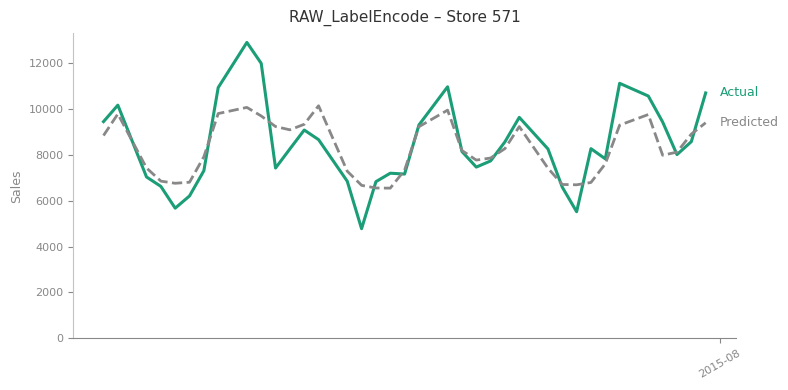

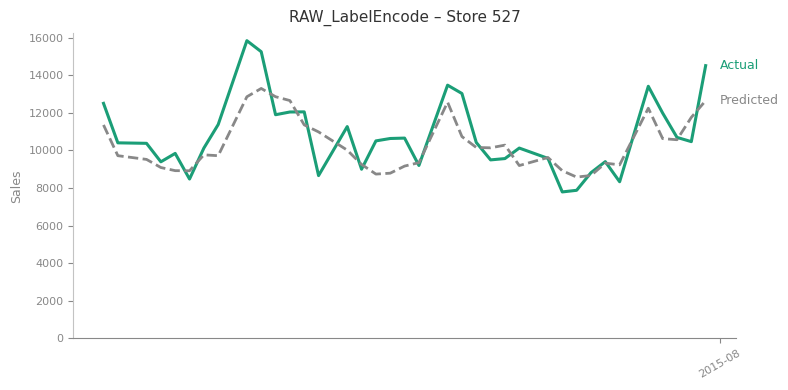

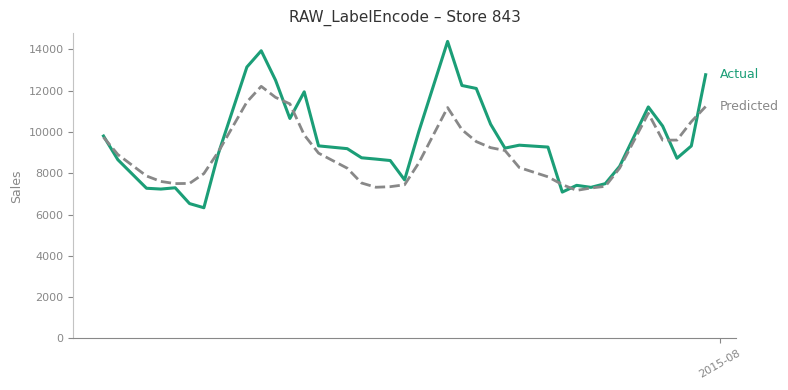


=== Optimized_FE ===


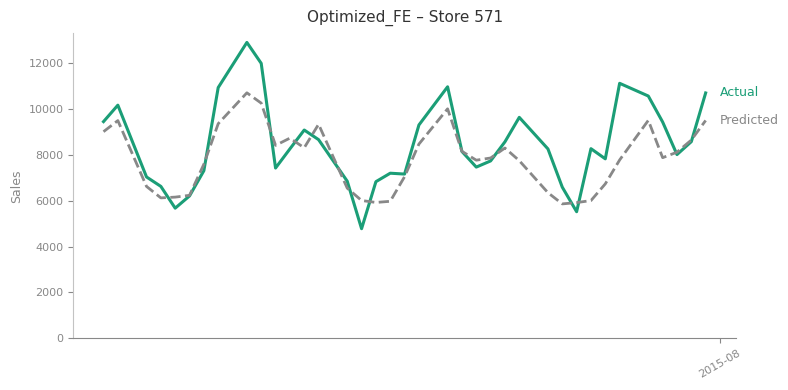

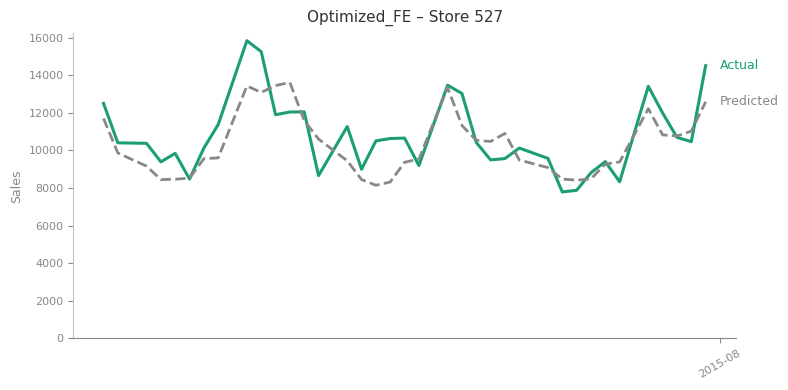

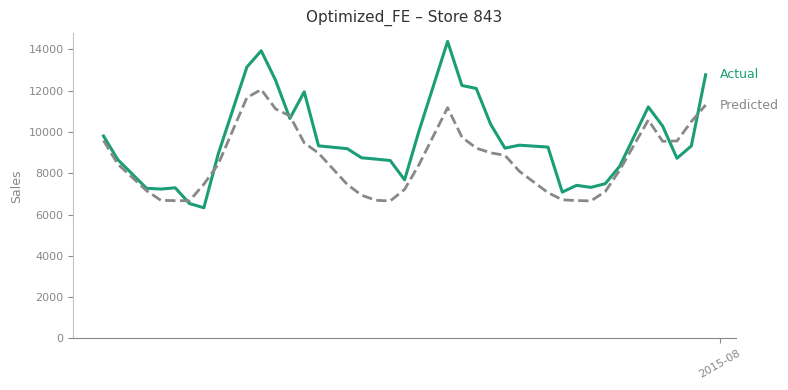


=== EntityEmbedding ===


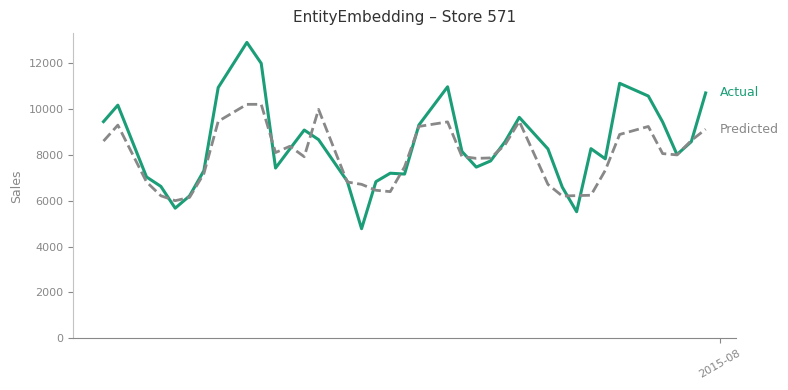

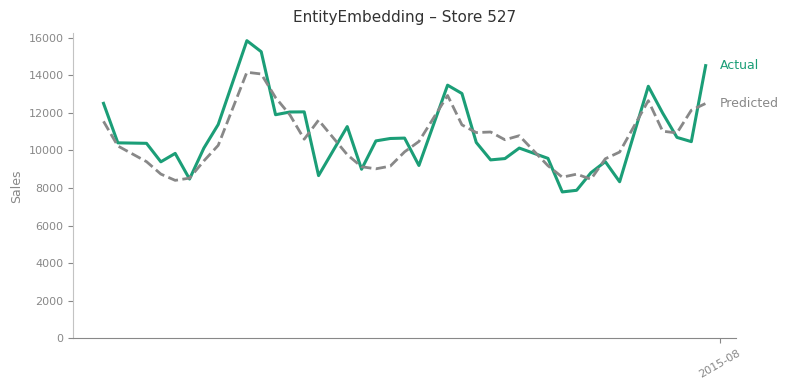

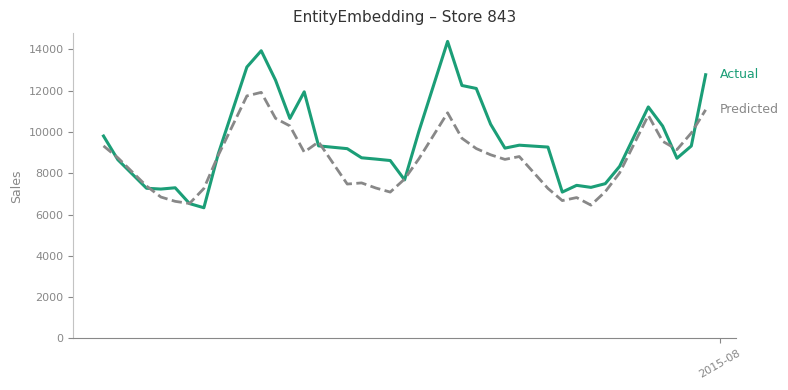

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======= Palette =======
TEAL_BASE        = "#1B9E77"  
ORANGE_HIGHLIGHT = "#D95F02"  
PURPLE_SUPPORT   = "#7570B3"  
PINK_SPECIAL     = "#E7298A"  

GRAY_NEUTRAL = '#888888'
GRAY_LIGHT   = '#C3C3C3'

plt.style.use("default")

def plot_store_series(df_pred, store_id, pipeline_name):
    sub = (
        df_pred[df_pred["Store"] == store_id]
        .sort_values("Date")
        .copy()
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Đường thực tế
    ax.plot(
        sub["Date"],
        sub["y_true"],
        label="Actual",
        linewidth=2.2,
        color=TEAL_BASE,
    )

    # Đường dự báo
    ax.plot(
        sub["Date"],
        sub["y_pred"],
        label="Predicted",
        linewidth=2.0,
        linestyle="--",
        color=GRAY_NEUTRAL,
    )

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=30, labelsize=8, colors=GRAY_NEUTRAL)
    ax.tick_params(axis="y", labelsize=8, colors=GRAY_NEUTRAL)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("", fontsize=9)
    ax.set_ylabel("Sales", fontsize=9, color=GRAY_NEUTRAL)

    ax.set_title(
        f"{pipeline_name} – Store {store_id}",
        fontsize=11,
        color="#333333",
        pad=8
    )

    # Label trực tiếp hai đường ở cuối
    last_date = sub["Date"].iloc[-1]
    offset_x = pd.Timedelta(days=1)

    ax.text(
        last_date + offset_x,
        sub["y_true"].iloc[-1],
        "Actual",
        color=TEAL_BASE,
        fontsize=9,
        va="center",
        ha="left"
    )

    ax.text(
        last_date + offset_x,
        sub["y_pred"].iloc[-1],
        "Predicted",
        color=GRAY_NEUTRAL,
        fontsize=9,
        va="center",
        ha="left"
    )

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY_LIGHT)
    ax.spines["bottom"].set_color(GRAY_NEUTRAL)

    plt.tight_layout()
    plt.show()

# Chọn 3 store ngẫu nhiên dùng chung cho mọi pipeline
rng = np.random.default_rng(1)

any_pipeline_df = next(iter(comparer.predictions_.values()))
store_list = np.sort(any_pipeline_df["Store"].unique())

n_examples = min(3, len(store_list))
chosen_stores = rng.choice(store_list, size=n_examples, replace=False)
print("Chọn 3 Store dùng chung cho mọi pipeline:", chosen_stores)

# Vẽ: với MỖI pipeline, lặp qua 3 store giống nhau
for pipeline_name, df_pred in comparer.predictions_.items():
    print(f"\n=== {pipeline_name} ===")
    for sid in chosen_stores:
        plot_store_series(df_pred, sid, pipeline_name)


## 2. “Soi” vào không gian Entity Embeddings

Rõ ràng là pipeline dùng Entity Embeddings dự báo tốt hơn.  
Câu hỏi tiếp theo là:

> Bên trong lớp embedding, mô hình thực sự đã học được **gì**?

Để trả lời, chúng mình:

- Load lại mạng embedding đã train cho pipeline Entity Embeddings,
- Trích xuất ma trận embedding cho mọi biến phân loại,
- Và tập trung phân tích embedding của **`Store`** – vì đây là biến mang nhiều “bản sắc” nhất của chuỗi.

Ý tưởng:

- Mỗi cửa hàng tương ứng với **một vector embedding** trong không gian nhiều chiều,
- Nếu embedding có ý nghĩa, những cửa hàng có **doanh thu gần nhau** phải nằm **gần nhau** trong không gian này.


In [15]:
from data_preparation.models import EntityEmbeddingModel

def load_trained_embedding_model(emb_processor: EntityEmbeddingFeatureGenerator) -> EntityEmbeddingModel:
    model = EntityEmbeddingModel(
        emb_processor.emb_dims,
        n_cont=len(emb_processor.cont_cols)
    )
    state_dict = torch.load(
        emb_processor.model_save_path,
        map_location=emb_processor.device
    )
    model.load_state_dict(state_dict)
    model.eval()
    return model

model_emb = load_trained_embedding_model(emb_proc)
model_emb


C:\Users\Admin\AppData\Local\Temp\ipykernel_18924\2064954939.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


EntityEmbeddingModel(
  (embeddings): ModuleList(
    (0): Embedding(1115, 50)
    (1): Embedding(7, 4)
    (2): Embedding(3, 2)
    (3): Embedding(12, 6)
    (4): Embedding(31, 16)
    (5-6): 2 x Embedding(4, 2)
    (7): Embedding(3, 2)
    (8): Embedding(4, 2)
    (9): Embedding(5, 3)
  )
  (fc1): Linear(in_features=96, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=512, out_features=1, bias=True)
  (relu): ReLU()
)

In [16]:
cat_to_W = {}
for i, col in enumerate(emb_proc.cat_cols):
    W = model_emb.embeddings[i].weight.detach().cpu().numpy()
    cat_to_W[col] = W

cat_to_W.keys()


dict_keys(['Store', 'DayOfWeek', 'Year', 'Month', 'Day', 'StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'WeekOfMonth'])

In [17]:
# 1. Vị trí cột 'Store' trong danh sách cat_cols
store_col_idx = emb_proc.cat_cols.index("Store")

# 2. Lấy embedding matrix của 'Store' từ model đã train
W_store = model_emb.embeddings[store_col_idx].weight.detach().cpu().numpy()
# shape: (n_stores, emb_dim)

# 3. Lấy lại danh sách Store theo đúng thứ tự index của embedding
le_store = emb_proc.label_encoders["Store"]

store_ids = np.array(le_store.classes_, dtype=int)

# 4. Mean sales theo Store
mean_sales = (
    train_df
        .loc[train_df["Sales"] > 0]
        .groupby("Store", as_index=False)["Sales"]
        .mean()
        .rename(columns={"Sales": "MeanSales"})
)

# 5. Ghép embedding + mean_sales
emb_cols = [f"Store_emb_{i}" for i in range(W_store.shape[1])]
df_store_emb = pd.DataFrame(W_store, columns=emb_cols)
df_store_emb.insert(0, "Store", store_ids)

store_emb_with_sales = df_store_emb.merge(mean_sales, on="Store", how="left")


### 2.1 PC1 của store embedding vs doanh thu trung bình

Ta áp dụng PCA lên ma trận embedding của `Store` và lấy **PC1** làm trục tóm tắt chính.
Khi vẽ scatter giữa `PC1` (trục x) và **doanh thu trung bình mỗi cửa hàng** (trục y), ta thấy một xu hướng **giảm rất rõ rệt**,
với đường hồi quy gần như tuyến tính:

> Các cửa hàng doanh thu **cao** tập trung về một phía của trục PC1 (bên trái),  
> còn các cửa hàng doanh thu **thấp** nằm về phía còn lại (bên phải).

Dấu của PC1 là tùy quy ước, nhưng điều quan trọng là:
embedding đã học được một **trục ẩn đơn chiều** liên quan trực tiếp tới “mức độ mạnh/yếu” về doanh thu của cửa hàng.


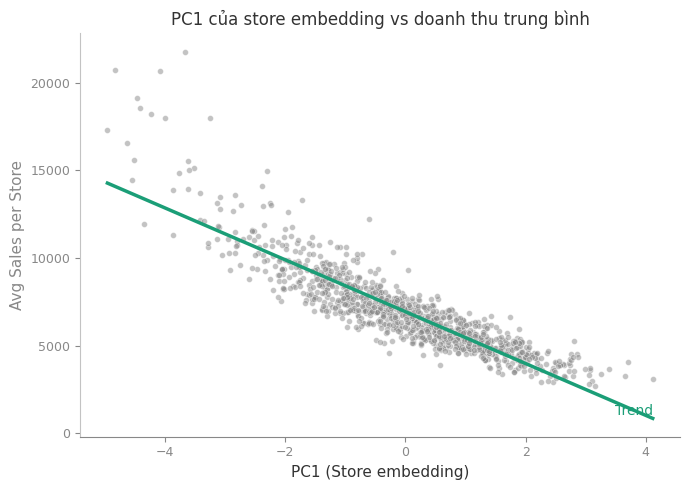

In [19]:
# =======palette =======
TEAL_BASE        = "#1B9E77"  # Đường xu hướng chính / baseline
ORANGE_HIGHLIGHT = "#D95F02"  # Dùng cho nhóm cần nhấn mạnh (nếu thêm)
PURPLE_SUPPORT   = "#7570B3"  # Nhóm bổ sung
PINK_SPECIAL     = "#E7298A"  # Nhóm đặc biệt / outlier

GRAY_DOT     = "#888888"
GRAY_NEUTRAL = "#888888"
GRAY_LIGHT   = "#C3C3C3"

# PCA cho store embedding
pca_store = PCA(n_components=4)
store_pcs = pca_store.fit_transform(W_store)

pc_df = pd.DataFrame({
    "Store": store_ids,
    "PC1": store_pcs[:, 0],
    "PC2": store_pcs[:, 1],
})
pc_df = pc_df.merge(mean_sales, on="Store", how="left")

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 1) Scatter: xám đậm, hơi trong
ax.scatter(
    pc_df["PC1"], pc_df["MeanSales"],
    alpha=0.5,
    s=18,
    edgecolor="white",
    linewidth=0.5,
    color=GRAY_DOT
)

# 2) Đường xu hướng tuyến tính (OLS)
coef = np.polyfit(pc_df["PC1"], pc_df["MeanSales"], deg=1)
x_line = np.linspace(pc_df["PC1"].min(), pc_df["PC1"].max(), 100)
y_line = coef[0] * x_line + coef[1]
ax.plot(
    x_line, y_line,
    linestyle="-",
    linewidth=2.5,
    color=TEAL_BASE
)

ax.text(
    x_line[-1],
    y_line[-1],
    "Trend",
    color=TEAL_BASE,
    fontsize=10,
    va="bottom",
    ha="right"
)

ax.set_xlabel("PC1 (Store embedding)", fontsize=11, color="#333333")
ax.set_ylabel("Avg Sales per Store", fontsize=11, color=GRAY_NEUTRAL)
ax.set_title("PC1 của store embedding vs doanh thu trung bình", fontsize=12, color="#333333")

# Declutter
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRAY_LIGHT)
ax.spines["bottom"].set_color(GRAY_NEUTRAL)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_NEUTRAL)

plt.tight_layout()
plt.show()


### 2.2 Phân phối các thành phần chính của embedding

Tiếp theo, chúng mình xem phân phối của các thành phần chính PC1–PC4:

- Các PC có phân phối tương đối “gọn”, không bị cực đoan,
- Không gian embedding vì thế khá **mượt**,
- Giúp những mô hình tuyến tính hơn ở tầng trên (như XGBoost ở tầng feature đã biến đổi)  
  dễ dàng khai thác thông tin mà không bị méo bởi outlier.

Nói cách khác, embedding đang sắp xếp các cửa hàng vào một không gian vector “dễ làm việc” hơn so với việc giữ nguyên các ID rời rạc.


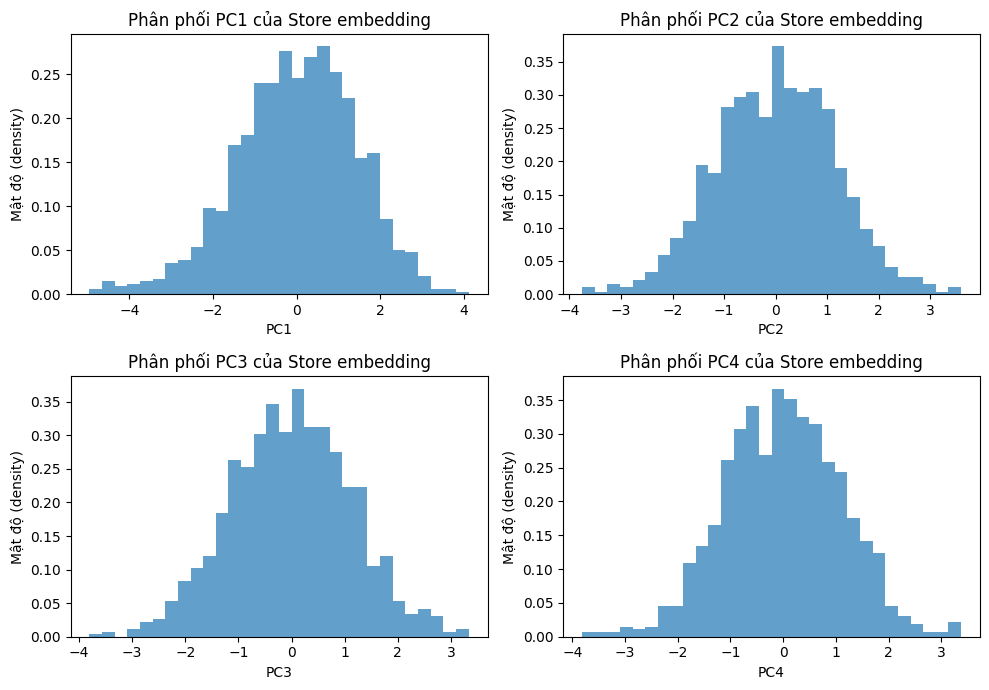

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for i in range(4):
    ax = axes.flat[i]
    ax.hist(store_pcs[:, i], bins=30, density=True, alpha=0.7)
    ax.set_title(f"Phân phối PC{i+1} của Store embedding")
    ax.set_xlabel(f"PC{i+1}")
    ax.set_ylabel("Mật độ (density)")

plt.tight_layout()
plt.show()


### 2.3 Cửa hàng càng khác doanh thu, vector embedding càng xa nhau

Cuối cùng, chúng mình chọn ngẫu nhiên rất nhiều **cặp cửa hàng** và so sánh:

- Trục x: chênh lệch doanh thu trung bình giữa hai cửa hàng (ở thang `log1p`),
- Trục y: khoảng cách Euclid giữa hai vector embedding tương ứng.

Biểu đồ scatter cho thấy một xu hướng rõ rệt:

> **Chênh lệch doanh thu càng lớn → hai điểm embedding càng xa nhau.**

Đây là bằng chứng trực quan rằng:

- Entity Embeddings đã học được mối quan hệ giữa **“mức độ doanh thu”** và **vị trí trong không gian vector**,
- Cửa hàng giống nhau về hành vi doanh thu nằm gần nhau,
- Cửa hàng rất khác nhau được đẩy ra xa.

Kết hợp với kết quả RMSPE và các biểu đồ Actual vs Predicted, chúng mình có thể kết luận:

> Việc chuẩn bị dữ liệu “tử tế” cho biến phân loại bằng Entity Embeddings  
> không chỉ cải thiện chất lượng dự báo,  
> mà còn tạo ra một không gian biểu diễn có ý nghĩa business,  
> giúp mô hình hiểu sâu hơn về hành vi của từng cửa hàng.


Embedding Store shape: (1115, 50), #stores = 1115
log_mean_sales range: 7.902759801285105 -> 9.987759002693922
Số cặp dùng để vẽ: 9988


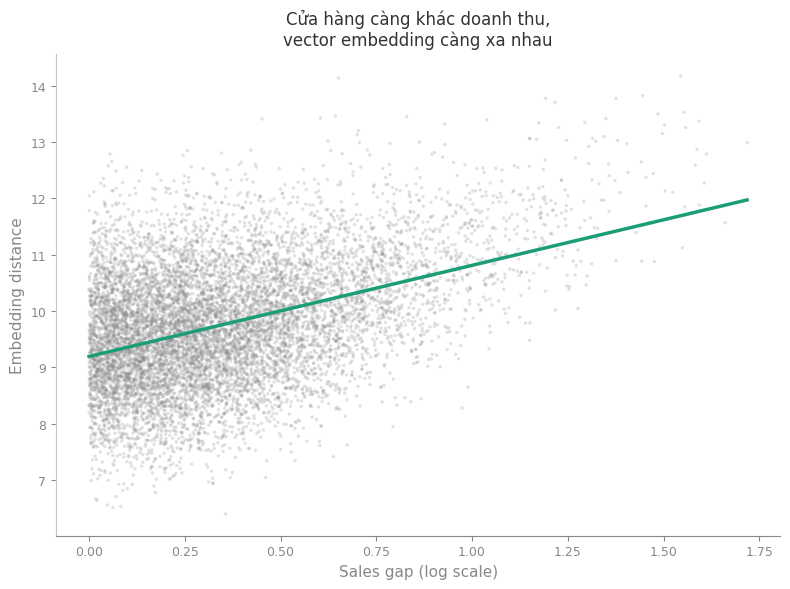

In [21]:
# 1. Lấy embedding và thứ tự store bên trong embedding
store_idx = emb_proc.cat_cols.index("Store")
W_store   = model_emb.embeddings[store_idx].weight.detach().cpu().numpy()  # (n_stores, emb_dim)

le_store  = emb_proc.label_encoders["Store"]
store_ids = le_store.classes_.astype(int)   # ID Store gốc tương ứng với từng hàng trong W_store

n_stores, emb_dim = W_store.shape
print(f"Embedding Store shape: {W_store.shape}, #stores = {n_stores}")

# 2. Tính metric value = log1p(mean Sales) per Store
mean_sales = comparer.full_data.groupby("Store")["Sales"].mean()
log_mean_sales = np.log1p(mean_sales)   # thu nhỏ thang đo

# Sắp xếp metric theo đúng thứ tự store_ids (khớp với W_store)
log_metric_vals = log_mean_sales.loc[store_ids].values  # shape (n_stores,)
print("log_mean_sales range:", log_metric_vals.min(), "->", log_metric_vals.max())

# 3. Lấy 10 000 cặp store ngẫu nhiên & tính khoảng cách
N_PAIRS = 10_000
rng = np.random.default_rng(42)

i_idx = rng.integers(0, n_stores, size=N_PAIRS)
j_idx = rng.integers(0, n_stores, size=N_PAIRS)

mask = i_idx != j_idx
i_idx = i_idx[mask]
j_idx = j_idx[mask]
print("Số cặp dùng để vẽ:", len(i_idx))

# distance trong metric space = |log_sales_i - log_sales_j|
metric_dists = np.abs(log_metric_vals[i_idx] - log_metric_vals[j_idx])

# distance trong embedding space = ||e_i - e_j||_2
embed_dists = np.linalg.norm(W_store[i_idx] - W_store[j_idx], axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 1) Scatter: background xám, rất nhạt
ax.scatter(
    metric_dists,
    embed_dists,
    s=6,
    alpha=0.25,
    edgecolor="none",
    color=GRAY_NEUTRAL
)

# 2) Smooth trend (bin trung bình hoặc polynomial nhẹ)
coef = np.polyfit(metric_dists, embed_dists, deg=1)
x_line = np.linspace(metric_dists.min(), metric_dists.max(), 100)
y_line = coef[0] * x_line + coef[1]
ax.plot(
    x_line,
    y_line,
    linewidth=2.5,
    color=TEAL_BASE
)

ax.set_xlabel("Sales gap (log scale)", fontsize=11, color=GRAY_NEUTRAL)
ax.set_ylabel("Embedding distance", fontsize=11, color=GRAY_NEUTRAL)
ax.set_title(
    "Cửa hàng càng khác doanh thu,\nvector embedding càng xa nhau",
    fontsize=12,
    color="#333333"
)

# Declutter
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRAY_LIGHT)
ax.spines["bottom"].set_color(GRAY_NEUTRAL)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_NEUTRAL)

plt.tight_layout()
plt.show()
